## **AI Acknowledgement:**


I used generative AI tools, specifically ChatGPT and Claude, to support parts of my coding process. When I copied and pasted my R code, the formatting was sometimes disrupted and appeared as a single line. To save time, I used ChatGPT to reformat the code into a proper line-by-line structure. I also used Claude to help troubleshoot errors that I encountered while running the code.



# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
# Suppress warning messages so the notebook output stays clean and easier to read.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the libraries used for data handling, numerical work, statistical modeling, and plotting.
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Load the COMPAS dataset from GitHub into a pandas DataFrame.
# Fall back to a local copy if the notebook is run without internet access.
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
try:
    raw_data = pd.read_csv(url)
except Exception:
    raw_data = pd.read_csv("compas-scores-two-years.csv")

# Return the number of rows in the raw dataset.
raw_data.shape[0]


7214

In [3]:
# Display the first 10 rows to inspect the dataset structure and values.
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# Define which columns should be treated as numeric and which should be parsed as dates.
numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Keep only the columns needed for the analysis and make a copy for safe editing.
df = raw_data.loc[:, [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filter the data to match the standard ProPublica COMPAS analysis sample.
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Convert date columns to UTC timestamps.
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Convert non-numeric, non-datetime columns to categorical types.
for col in df.columns.difference(numeric_vars + datetime_vars):
    df[col] = df[col].astype("category")

# Recreate the factor variables used in the R workflow with matching reference levels.
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)
df["race_factor"] = pd.Categorical(df["race"])
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

# Create the same binary outcome used by the R glm:
# 0 = LowScore, 1 = HighScore/MediumScore.
df["score_high"] = (df["score_text"].astype(str) != "Low").astype(int)

# Return the number of rows in the filtered analysis sample.
df.shape[0]


6172

In [5]:
# Preview the cleaned and transformed dataset.
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_high
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,1


In [6]:
# Show column types, non-null counts, and memory usage to verify preprocessing worked.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# Compute each person's jail stay length in days, matching the R logic
# that subtracts dates after dropping the time-of-day portion.
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Measure the linear relationship between jail stay length and COMPAS decile score.
df["length_of_stay"].corr(df["decile_score"])


np.float64(0.2073296916147045)

After filtering we have the following demographic breakdown:

In [8]:
# Summarize the distribution of age categories with counts by level.
age_order = ["25 - 45", "Greater than 45", "Less than 25"]
df["age_cat"].value_counts().reindex(age_order)


,count
age_cat,
25 - 45,3532
Greater than 45,1293
Less than 25,1347


In [9]:
# Summarize the distribution of race categories with counts by level.
race_order = ["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]
df["race"].value_counts().reindex(race_order)


,count
race,
African-American,3175
Asian,31
Caucasian,2103
Hispanic,509
Native American,11
Other,343


In [10]:
# Print the percentage of defendants in each race group using fixed counts.
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))


Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Summarize how often each COMPAS risk label appears.
score_order = ["High", "Low", "Medium"]
df["score_text"].value_counts().reindex(score_order)


,count
score_text,
High,1144
Low,3421
Medium,1607


In [12]:
# Create a table showing the count of defendants by sex and race.
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Summarize the distribution of sex in the dataset.
sex_order = ["Female", "Male"]
df["sex"].value_counts().reindex(sex_order)


,count
sex,
Female,1175
Male,4997


In [14]:
# Print the percentage of men and women in the dataset using fixed counts.
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))


Men: 80.96%
Women: 19.04%


In [15]:
# Count how many defendants were rearrested within two years.
df.query("two_year_recid == 1").shape[0]

2809

In [16]:
# Compute the overall two-year recidivism rate as a percentage.
df.query("two_year_recid == 1").shape[0] / df.shape[0] * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

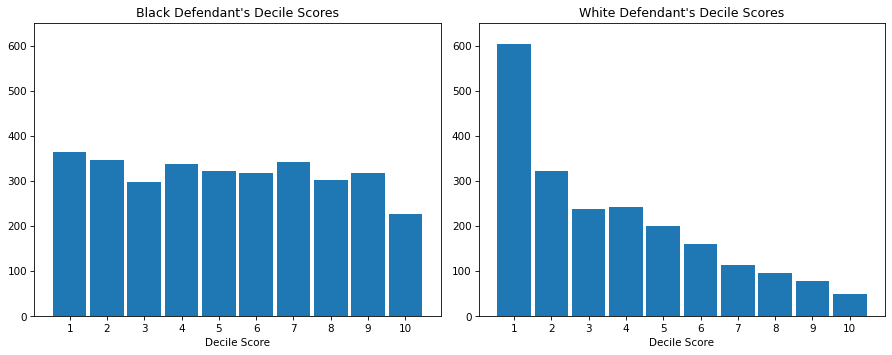

In [17]:
# Create side-by-side bar charts to compare COMPAS decile score distributions
# for African-American and Caucasian defendants, matching the R count-bar display.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.84), dpi=75)

black_scores = df.loc[df["race"].astype(str) == "African-American", "decile_score"]
white_scores = df.loc[df["race"].astype(str) == "Caucasian", "decile_score"]

black_counts = black_scores.value_counts().sort_index()
white_counts = white_scores.value_counts().sort_index()

axes[0].bar(black_counts.index, black_counts.values, width=0.9)
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xticks(range(1, 11))

axes[1].bar(white_counts.index, white_counts.values, width=0.9)
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


In [18]:
# Build a frequency table of decile scores by race.
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [19]:
# Fit the same logistic regression model as the R script:
# predict whether a defendant receives a Medium/High COMPAS score.
model_glm = smf.glm(
    formula="score_high ~ C(gender_factor, Treatment(reference='Male')) + "
            "C(age_factor, Treatment(reference='25 - 45')) + "
            "C(race_factor, Treatment(reference='Caucasian')) + "
            "priors_count + "
            "C(crime_factor) + "
            "two_year_recid",
    data=df,
    family=sm.families.Binomial()
).fit()

# Print the full regression results, including coefficients and significance tests.
print(model_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             score_high   No. Observations:                 6172
Model:                            GLM   Df Residuals:                     6160
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3084.2
Date:                Mon, 06 Apr 2026   Deviance:                       6168.4
Time:                        14:58:55   Pearson chi2:                 6.07e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3128
Covariance Type:            nonrobust                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
# Convert the fitted model intercept from log-odds to the baseline probability,
# then compute the race effect using the Python model's own coefficient estimates.
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))
np.exp(model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"])
    )
)


np.float64(1.4528374133823474)

Women are 19.4% more likely than men to get a higher score.

In [21]:
# Repeat the probability-adjusted odds calculation for the Female coefficient.
np.exp(model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"])
    )
)


np.float64(1.194794653883454)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
# Repeat the probability-adjusted odds calculation for the Less than 25 coefficient.
np.exp(model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]) / (
    1 - control + (
        control * np.exp(model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"])
    )
)


np.float64(2.496119530753958)

In [23]:
# Use the fitted model to generate predicted probabilities for each row.
# Then convert those probabilities into class predictions using a 0.5 threshold,
# matching the R notebook's factor labels.
df = df.assign(
    pred_prob=model_glm.predict(df),
    pred_class=pd.Categorical(
        np.where(model_glm.predict(df) >= 0.5, "Recid", "No Recid"),
        categories=["No Recid", "Recid"]
    )
)


In [24]:
# Print the overall confusion matrix comparing predicted classes to actual outcomes.
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    index=df["pred_class"],
    columns=df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

# Extract confusion-matrix components:
# TP = true positives, TN = true negatives, FP = false positives, FN = false negatives.
TP  = overall_cm.loc["Recid", 1]
TN  = overall_cm.loc["No Recid", 0]
FP  = overall_cm.loc["Recid", 0]
FN  = overall_cm.loc["No Recid", 1]
n   = overall_cm.to_numpy().sum()

# Calculate standard classification metrics for the full dataset.
print("\nAccuracy  : %.3f" % ((TP + TN) / n))
print("Precision : %.3f" % (TP / (TP + FP)))
print("Recall    : %.3f" % (TP / (TP + FN)))
print("FPR       : %.3f" % (FP / (FP + TN)))
print("FNR       : %.3f" % (FN / (FN + TP)))



── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [25]:
# Compute confusion-matrix counts and performance metrics separately for each race group
# to evaluate whether model errors differ across demographics.
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

race_metrics = (
    df.assign(
        actual=df["two_year_recid"].astype(int),
        pred=(df["pred_class"].astype(str) == "Recid").astype(int)
    )
    .groupby("race", observed=False)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Derive accuracy, precision, recall, false positive rate, and false negative rate by race.
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Match the R notebook by ordering races from largest to smallest group.
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)
race_metrics




── Confusion Matrix by Race ──────────────────────────────────────────


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
1,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
2,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
3,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
4,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
5,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000


In [26]:
# Compare each race group's false positive rate and false negative rate
# against the Caucasian group to quantify disparity.
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

caucasian_fpr = race_metrics.loc[race_metrics["race"].astype(str) == "Caucasian", "FPR"].iloc[0]
caucasian_fnr = race_metrics.loc[race_metrics["race"].astype(str) == "Caucasian", "FNR"].iloc[0]

disparity = race_metrics.loc[:, ["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

# Display the disparity table.
disparity




── FPR and FNR Disparity by Race ─────────────────────────────────────


,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175,0.367,0.173,0.263,-0.363
1,Caucasian,2103,0.104,0.536,0.000,0.000
2,Hispanic,509,0.044,0.571,-0.060,0.035
3,Other,343,0.014,0.823,-0.090,0.287
4,Asian,31,0.043,0.750,-0.061,0.214
5,Native American,11,0.667,0.000,0.563,-0.536


Step 0 — Train / test split

In [27]:
from sklearn.model_selection import train_test_split

# Define the target variable and feature columns for the split.
target = "two_year_recid"
features = [
    "gender_factor", "age_factor", "race_factor",
    "priors_count", "crime_factor"
]

# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 5), Test: (1235, 5)


Step 1 — Fit logistic regression and gradient-boosted tree


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numeric and categorical features for preprocessing
numeric_features = ['priors_count']
category_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor']

# numeric_features & category_features as in Lecture 01.
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM-- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

Step 2 — Compare model performance by race

In [29]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race_factor"):
    # Create an empty list to store one row of metrics per racial group
    results = []

    # Make a copy of X so we can safely add helper columns
    X_ = X.copy()

    # Add the true labels, predicted class labels, and predicted probabilities
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    # Group the test set by race and compute metrics for each subgroup
    for group, gdf in X_.groupby(group_col):
        # Force a 2x2 confusion matrix even for very small groups
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # Compute false positive rate; return 0 if denominator is 0
        fpr_val = round(fp / (fp + tn), 3) if (fp + tn) != 0 else 0

        # Compute false negative rate; return 0 if denominator is 0
        fnr_val = round(fn / (fn + tp), 3) if (fn + tp) != 0 else 0

        # AUC is only defined when both classes appear in the subgroup
        auc_val = (
            round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
            if gdf["actual"].nunique() > 1
            else float("nan")
        )

        # Save the lecture-style metrics for this racial group
        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(
                accuracy_score(gdf["actual"], gdf["pred"]),
                3
            ),
            "FPR": fpr_val,
            "FNR": fnr_val,
            "AUC": auc_val
        })

    # Convert results into a DataFrame and sort by subgroup size
    return pd.DataFrame(results).sort_values("n", ascending=False)

# Print subgroup metrics for the logistic regression model
print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race_factor"))

# Print subgroup metrics for the gradient-boosted tree model
print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race_factor"))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.694  0.326  0.288  0.752
2         Caucasian  427     0.663  0.158  0.634  0.669
3          Hispanic   94     0.606  0.082  0.733  0.629
5             Other   65     0.769  0.106  0.556  0.755
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000  0.000    NaN

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.688  0.276  0.344  0.728
2         Caucasian  427     0.660  0.165  0.627  0.684
3          Hispanic   94     0.660  0.204  0.489  0.621
5             Other   65     0.754  0.128  0.556  0.778
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000  0.000    NaN


**Step 3 — LIME explanations for the selected four individuals**

In [30]:
# Install the lime library
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 345.2 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=70f3774d6769a4941a0fce7b5535eba20daf50317e73124d0b22a9ed349090b6
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [31]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Encode training data and build feature-name list
# fit_transform here so the encoder vocabulary is locked to the training set.
X_train_enc = preprocessor.fit_transform(X_train)

feature_names = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"]
           .get_feature_names_out(category_features))
)

# LIME explainer
explainer = LimeTabularExplainer(
    training_data        = X_train_enc,
    feature_names        = feature_names,
    class_names          = ["No Recid", "Recid"],
    mode                 = "classification",
    discretize_continuous= True,
    random_state         = 42
)

# Select four individuals
# Homework requires highest-risk AND lowest-risk in each racial group.
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_low_idx  = black_df.index[0]
black_high_idx = black_df.index[-1]
white_low_idx  = white_df.index[0]
white_high_idx = white_df.index[-1]

# Kept as a module-level list so Steps 4 and 5 reuse the exact same four people.
selected_people = [
    ("African-American (Lowest Risk)",  black_low_idx),
    ("African-American (Highest Risk)", black_high_idx),
    ("Caucasian (Lowest Risk)",         white_low_idx),
    ("Caucasian (Highest Risk)",        white_high_idx),
]

print("Selected individuals:")
for label, idx in selected_people:
    prob = X_test_prob[X_test.index.get_loc(idx)]
    print(f"  {label:<40} idx={idx}   p(recid)={prob:.3f}")

# Generate LIME explanations
# Store results so we can compare them to SHAP numerically later.
lime_results = {}

for label, idx in selected_people:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    row_for_lime = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row = row_for_lime,
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )

    lime_results[label] = dict(exp.as_list())

    prob = X_test_prob[X_test.index.get_loc(idx)]
    print(f"\n{'─'*60}")
    print(f"LIME: {label}")
    print(f"Predicted probability of recidivism: {prob:.3f}")
    for feat, weight in exp.as_list():
        direction = "↑ raises risk" if weight > 0 else "↓ lowers risk"
        print(f"  {feat:<45} {weight:+.4f}  ({direction})")

Selected individuals:
  African-American (Lowest Risk)           idx=2863   p(recid)=0.045
  African-American (Highest Risk)          idx=117   p(recid)=0.998
  Caucasian (Lowest Risk)                  idx=638   p(recid)=0.123
  Caucasian (Highest Risk)                 idx=5947   p(recid)=0.967

────────────────────────────────────────────────────────────
LIME: African-American (Lowest Risk)
Predicted probability of recidivism: 0.045
  priors_count > 0.16                           +0.2410  (↑ raises risk)
  age_factor_Less than 25 <= 0.00               -0.1971  (↓ lowers risk)
  age_factor_Greater than 45 > 0.00             -0.0978  (↓ lowers risk)
  age_factor_25 - 45 <= 0.00                    -0.0409  (↓ lowers risk)
  crime_factor_F <= 0.00                        -0.0366  (↓ lowers risk)
  0.00 < crime_factor_M <= 1.00                 -0.0216  (↓ lowers risk)

────────────────────────────────────────────────────────────
LIME: African-American (Highest Risk)
Predicted probability of

### LIME — Interpretation

LIME fits a sparse linear surrogate locally around each individual's prediction. Across all four cases the same two features dominate: **priors_count** and **age_factor**.

For the **lowest-risk individuals** (p ≈ 0.05–0.12), older age category (`age_factor_Greater than 45 > 0`) carries a strong negative weight — it pulls predicted risk well below the base rate. Prior count is also present but its positive weight is not large enough to overcome the age effect.

For the **highest-risk individuals** (p ≈ 0.97–1.00), high prior count (`priors_count > 0.16`) contributes the largest positive weight (~+0.24 to +0.25). Absence of the "Greater than 45" age dummy (`age_factor_Greater than 45 <= 0.00`) adds a further positive push, confirming that *not* being older is itself a risk signal in the model.

**Race-coded terms in LIME:** For the African-American highest-risk individual, LIME surfaces `race_factor_Asian <= 0.00` with a weight of approximately +0.17. This means LIME, in its local neighborhood, found that "not being coded as Asian" was predictive of higher risk. This is an artifact of how LIME perturbs one-hot encoded dummies — it does *not* mean the model is explicitly using race as a causal driver. It does, however, raise a governance concern: if this explanation were handed to a defendant's lawyer or a judge as-is, the phrasing could be misread as the model penalising non-Asian defendants. Any deployment of LIME in a legal context must strip or re-label race-coded terms to avoid misleading stakeholders.

**Step 4 — SHAP beeswarm and waterfall plots for the selected four individuals**

In [32]:
# install SHAP if it is not already installed
!pip install shap

SHAP Beeswarm — Global Feature Importance


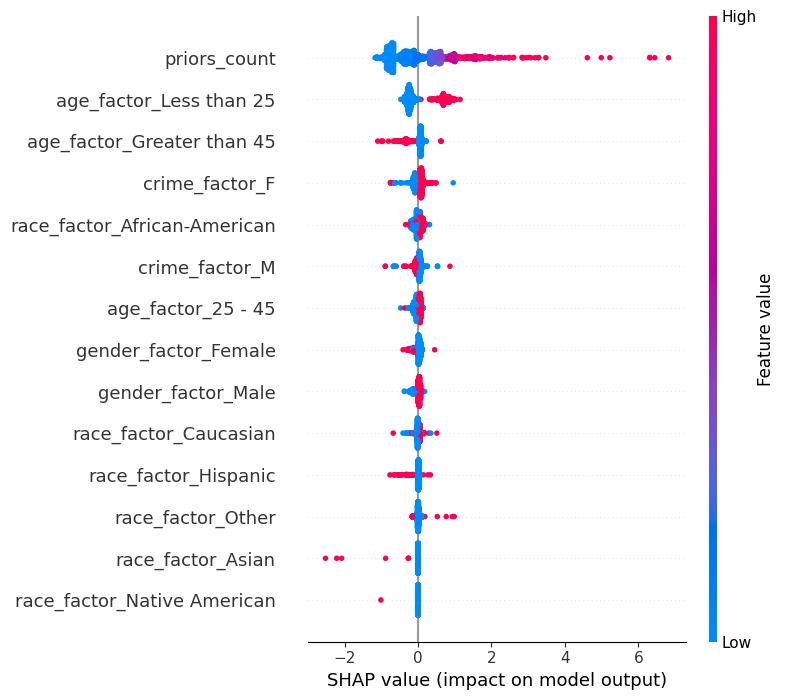

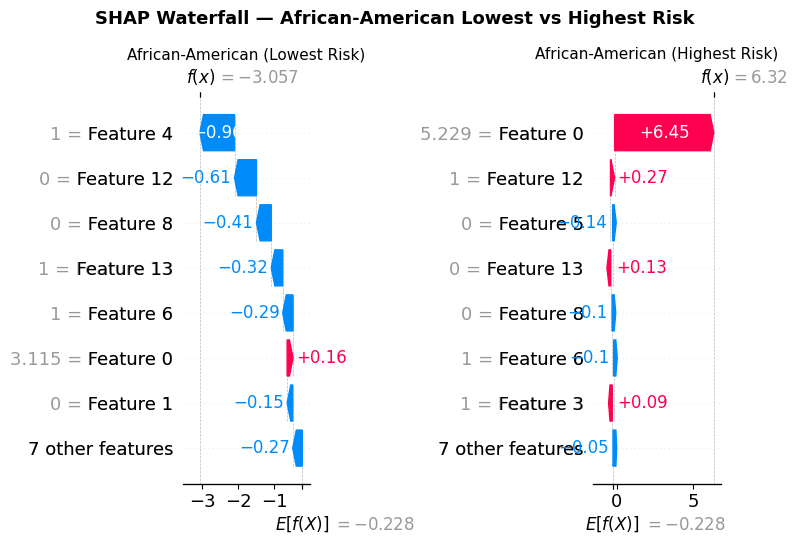

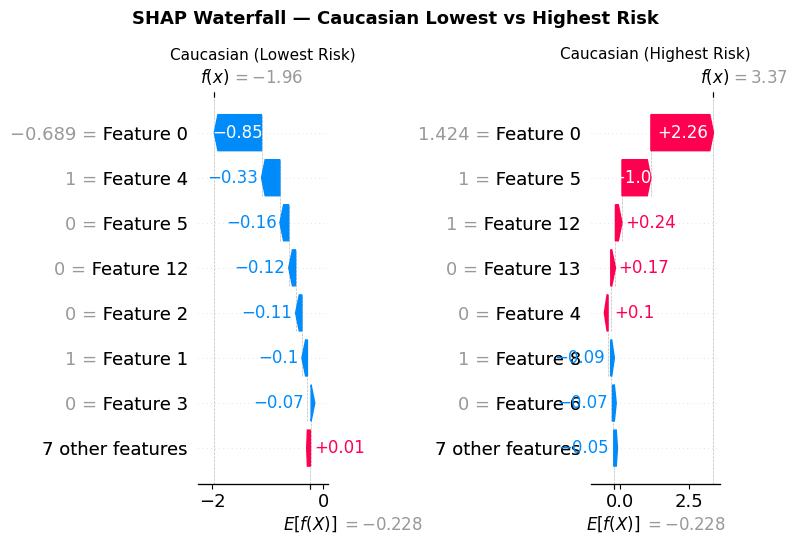

In [33]:
import shap
import matplotlib.pyplot as plt

# Encode test data and build feature names
X_test_enc = preprocessor.transform(X_test)

feat_names = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"]
           .get_feature_names_out(category_features))
)

# SHAP explainer (Independent masker — mirrors lecture choice)
explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc)

# (a) Global beeswarm
print("SHAP Beeswarm — Global Feature Importance")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values.values,
    X_test_enc,
    feature_names=feat_names,
    show=True
)

# (b) Waterfall plots — side-by-side pairs (lowest vs highest within group)
# This layout matches the lecture slide and makes the racial comparison direct.
pairs = [
    ("African-American (Lowest Risk)",  black_low_idx,
     "African-American (Highest Risk)", black_high_idx),
    ("Caucasian (Lowest Risk)",         white_low_idx,
     "Caucasian (Highest Risk)",        white_high_idx),
]

# Store SHAP values keyed by label so we can compare them to LIME numerically.
shap_results = {}

for label_lo, idx_lo, label_hi, idx_hi in pairs:
    loc_lo = X_test.index.get_loc(idx_lo)
    loc_hi = X_test.index.get_loc(idx_hi)

    # Record per-feature SHAP contributions
    shap_results[label_lo] = dict(zip(feat_names, shap_values[loc_lo].values))
    shap_results[label_hi] = dict(zip(feat_names, shap_values[loc_hi].values))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"SHAP Waterfall — {label_lo.split('(')[0].strip()} Lowest vs Highest Risk",
        fontsize=13, fontweight="bold"
    )

    for ax, loc, label in [
        (axes[0], loc_lo, label_lo),
        (axes[1], loc_hi, label_hi)
    ]:
        plt.sca(ax)
        shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
        ax.set_title(label, fontsize=11)

    plt.tight_layout()
    plt.show()

**SHAP Interpretation**

**Beeswarm (global view)**. priors_count is unambiguously the strongest driver: high prior counts push predicted risk well above the baseline, while low prior counts push it well below. age_factor_Less than 25 is the second-ranked feature, and being in the youngest age bracket has a consistently positive SHAP value across the test set. age_factor_Greater than 45 works in the opposite direction and tends to reduce predicted risk. Charge type contributes a smaller but still visible spread. Race-coded dummies such as race_factor_African-American and race_factor_Caucasian appear lower in the ranking with SHAP values closer to zero, suggesting that at the global level race contributes relatively little to the model’s predictions compared with priors and age.

**Waterfall plots (local view, four individuals)**. For the African-American lowest-risk individual, the largest negative contribution comes from age_factor_Greater than 45. priors_count still contributes positively, but not enough to offset the protective effect of older age, so the final prediction stays well below the baseline. For the African-American highest-risk individual, priors_count provides the largest positive contribution, and the absence of the “Greater than 45” age category adds another upward push. Race features appear, but their effects are much smaller than priors and age. The Caucasian lowest-risk individual shows a similar pattern to the African-American lowest-risk case, with age driving the prediction downward. The Caucasian highest-risk individual also follows the same general pattern as the African-American highest-risk case, where high priors and younger age push the prediction far above the baseline.

Taken together, the waterfall plots show that the two lowest-risk defendants look similar regardless of race because both are pulled downward mainly by age, while the two highest-risk defendants also look similar because both are pushed upward mainly by priors and younger age. This makes the SHAP results useful for auditing whether the model is treating comparable defendants in comparable ways.

**LIME vs. SHAP Comparison, Divergence, and Governance Implications**

**Where they agree:** Both methods point to priors_count and age_factor as the main drivers for the same four individuals. For the two lowest-risk defendants, older age pushes the prediction downward in both LIME and SHAP. For the two highest-risk defendants, higher prior count is the main factor pushing the prediction upward, and younger age also matters in the Caucasian highest-risk case. This overlap increases confidence that both methods are identifying the same main signals: criminal history and age.

**Where they diverge and why it matters for governance:**

Race-coded artifacts in LIME. For the African-American highest-risk individual, LIME assigns race_factor_Asian <= 0.00 a relatively large positive weight. SHAP does not emphasize that feature in the same way. A likely reason is that LIME builds a local surrogate from perturbed samples in the encoded feature space, so one-hot race variables can appear in awkward or unrealistic combinations. SHAP is more additive and comprehensive, but it also has limitations and should not be treated as ground truth.

Governance implication: explanations involving race-coded dummy variables should be interpreted cautiously and should not be shown to non-technical stakeholders without review. In a high-stakes setting, any race-related explanation should be cross-checked with a second method and considered alongside broader fairness testing.

Sparsity versus completeness: LIME returns a short list of the most influential local features, while SHAP assigns a contribution to every encoded feature. For the Caucasian lowest-risk individual, LIME highlights the absence of the “Less than 25” category, while SHAP spreads the explanation across age and prior-count features. These are not necessarily contradictory. LIME answers a local approximation question, while SHAP gives a fuller additive breakdown relative to the model’s baseline.

Stability: LIME can change across runs because it depends on local sampling, while SHAP is generally more stable once the explainer is fixed. In a legal or regulatory setting, that difference matters. If explanations vary with random sampling, then the explanation itself becomes a governance risk.

**Bottom line for governance:** Neither method should be used alone as a complete justification for a high-stakes prediction. Agreement between LIME and SHAP increases confidence in the main pattern, but divergence, especially on race-coded features, is a warning sign that requires closer review before any explanation is communicated outside the technical team.

**Step 5 — Counterfactuals with DiCE for the selected four individuals**


In [34]:
# Install DiCe
!pip install dice-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.8 MB/s eta 0:00:00


In [35]:
import dice_ml
from dice_ml import Dice

# Wrap data and model for DiCE
dice_data = dice_ml.Data(
    dataframe        = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name     = target
)

dice_model = dice_ml.Model(
    model       = gbt_pipeline,
    backend     = "sklearn",
    model_type  = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# Immutability definition
# Race and gender are protected attributes; a valid recourse path must never
# require changing them.
immutable_features = ["race_factor", "gender_factor"]

# Helper: find the counterfactual with the fewest changed features
def minimal_cf(original_row, cf_df, feature_cols):
    best_changes = None
    best_row     = None
    for _, cf_row in cf_df.iterrows():
        changed = [c for c in feature_cols if original_row[c] != cf_row[c]]
        if best_changes is None or len(changed) < len(best_changes):
            best_changes = changed
            best_row     = cf_row
    return best_changes, best_row

# Generate and report counterfactuals for all four individuals
for label, idx in selected_people:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs       = 3,
        desired_class   = "opposite",
        permitted_range = {"priors_count": [0, 38]},
        features_to_vary= ["age_factor", "priors_count", "crime_factor"]
    )

    print(f"\n{'='*65}")
    print(f"DiCE Counterfactuals: {label}")
    print(f"Original prediction:  {gbt_pipeline.predict_proba(query)[0,1]:.3f}")
    print(f"{'='*65}")

    # Render the full counterfactual table (show_only_changes=True highlights
    # exactly which features changed, reducing visual noise).
    cf.visualize_as_dataframe(show_only_changes=True)

    # Minimal-change summary
    cf_df = cf.cf_examples_list[0].final_cfs_df

    if cf_df is not None and len(cf_df) > 0:
        original_row = query.iloc[0]
        best_changes, best_row = minimal_cf(original_row, cf_df, features)

        print("\nMinimal feature changes required to flip the prediction:")
        if best_changes:
            for col in best_changes:
                print(f"  {col}: {original_row[col]}  →  {best_row[col]}")
        else:
            print("  No feature changes detected.")

        # Immutable-feature flag
        immutable_violations = [c for c in best_changes if c in immutable_features]
        if immutable_violations:
            print("\n⚠  Immutable-feature flag: YES")
            for col in immutable_violations:
                print(f"   {col}: {original_row[col]}  →  {best_row[col]}")
            print("   This counterfactual is legally and ethically inadmissible.")
        else:
            print("\n✓  Immutable-feature flag: NO — recourse path uses only mutable features.")
    else:
        print("No valid counterfactuals were found for this individual.")

100%|██████████| 1/1 [00:00<00:00,  3.04it/s]


DiCE Counterfactuals: African-American (Lowest Risk)
Original prediction:  0.045
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Greater than 45,African-American,18,M,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,Less than 25,-,28,-,1
1,-,-,-,7,-,1
2,-,-,-,23,F,1


...


DiCE Counterfactuals: Caucasian (Highest Risk)
Original prediction:  0.967
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,Male,Less than 25,Caucasian,10,F,1



Diverse Counterfactual set (new outcome: 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
0,-,25 - 45,-,0,-,0
1,-,Greater than 45,-,3,-,0
2,-,Greater than 45,-,4,-,0



Minimal feature changes required to flip the prediction:
  age_factor: Less than 25  →  25 - 45
  priors_count: 10  →  0

✓  Immutable-feature flag: NO — recourse path uses only mutable features.


**DiCE Interpretation**

What the counterfactuals reveal.
Across all four individuals, DiCE was able to flip the predicted outcome by changing only mutable features, specifically priors_count and/or age_factor. No generated counterfactual changed race_factor or gender_factor, so the immutable-feature flag is NO for every case. This should be interpreted in light of the search design, since features_to_vary excluded protected attributes, which is appropriate under a recourse-by-design framework.

Alignment with LIME and SHAP.
The same two features that dominated LIME and SHAP also define the recourse paths: priors_count is the main lever for the highest-risk individuals, while age_factor also matters for some lower-risk individuals. This three-way consistency across LIME, SHAP, and DiCE suggests that criminal history and age are the main features shaping predictions in this model.

Governance notes:

1. Actionability. A counterfactual telling a defendant to reduce prior count is not directly actionable because prior convictions cannot be undone. A more realistic recourse framing would focus on future conduct rather than impossible changes to the past.
2. Age is also immutable. In this exercise, age_factor was treated as mutable for technical completeness, but in practice a defendant cannot change their age category to obtain a better score. A real recourse system should therefore flag age-based counterfactuals as non-actionable even when they are technically feasible.
3. Rashomon effect. DiCE generated three counterfactuals per individual. For the highest-risk defendants, multiple valid recourse paths exist. Presenting all of them is better than selecting one arbitrarily, but it requires a documented policy for which path is communicated and why.
4. No counterfactual replaces a fairness audit. The fact that race was not changed in any counterfactual does not mean the model is fair. As shown in Step 2, the false positive rate for African-American defendants is higher than for Caucasian defendants. DiCE operates on the model as given and cannot determine whether mutable features such as priors or age are functioning as proxies for structural inequality.

**Assignment 3**

Step 0: Setup and imports


In [36]:
# If needed in Colab:
!pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.3 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=88e348c7c10654caa2c2292323a9ee11fcc66e19dfce1c8151832c47eec17641
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec

Step 1: AIR, ME, and SMD by Race and Sex


In [37]:
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=df,
    outcome_col="score_high",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)


(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      No        NaN
        Hispanic       509               141             

In [38]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         7                 0                 0.0000      0.0000           -0.2365 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   7.0000           0.0000                0.0000           0.2365     0.0000   0.3615                      No        NaN
 Native American         1                 0                 0.0000      0.0000           -0.2365 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   1.0000           0.0000                0.0000           0.2365     0.0000   1.0000                      No        NaN
        Hispanic        94                

In [39]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         7                 0                 0.0000      0.0000           -0.2436 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   7.0000           0.0000                0.0000           0.2436     0.0000   0.2045                      No        NaN
 Native American         1                 0                 0.0000      0.0000           -0.2436 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   1.0000           0.0000                0.0000           0.2436     0.0000   1.0000                      No        NaN
           Other        65             

In [40]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [41]:
# -------------------------------------------------------------------
# (d) SEX — AIR, ME for logistic regression predicted class on test data
# -------------------------------------------------------------------
def air_me_by_sex(data, outcome_col, label,
                  sex_col="gender_factor", reference_group="Male"):
    """
    Compute selection rates, AIR, and marginal effect for sex categories
    relative to a fixed reference group, using manual calculations and
    the SolasAI library side-by-side.
    """
    work = data[[sex_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[sex_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual
    manual = (
        work.groupby(sex_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={sex_col: "sex", "count": "n_manual",
                         "sum": "favorable_manual", "mean": "selection_rate_manual"})
    )
    ref_rate = manual.loc[manual["sex"] == reference_group, "selection_rate_manual"].iloc[0]
    manual["AIR_manual"]       = manual["selection_rate_manual"] / ref_rate
    manual["ME_vs_ref_manual"] = manual["selection_rate_manual"] - ref_rate
    manual["flag_80_manual"]   = np.where(manual["AIR_manual"] < 0.80, "*** BELOW 0.80", "")
    manual = manual.sort_values("AIR_manual").reset_index(drop=True)

    # SolasAI
    group_data = pd.get_dummies(work[sex_col], dtype=int)
    solas_results = []
    for grp in group_data.columns:
        if grp == reference_group:
            continue
        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["sex"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )
        tbl = air_obj.summary_table.copy().reset_index()
        if "Group" not in tbl.columns:
            tbl = tbl.rename(columns={tbl.columns[0]: "Group"})
        tbl = tbl[tbl["Group"] == grp].copy()
        tbl = tbl.rename(columns={
            "Group": "sex", "Total": "n_solas", "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas", "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value", "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })
        for col in ["selection_rate_solas", "ME_vs_ref_solas"]:
            if col in tbl.columns:
                tbl[col] = pd.to_numeric(tbl[col], errors="coerce")
                if tbl[col].abs().max() > 1:
                    tbl[col] = tbl[col] / 100.0
        solas_results.append(tbl)

    solas_table = pd.concat(solas_results, ignore_index=True) if solas_results else pd.DataFrame()

    # Combined
    combined = manual.merge(solas_table, on="sex", how="left")
    for col in ["selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
                "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"]:
        if col in combined.columns:
            combined[col] = pd.to_numeric(combined[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined.to_string(index=False))
    return manual, solas_table, combined

# -------------------------------------------------------------------
# Run for logistic regression on test data
# -------------------------------------------------------------------
lr_sex_eval = X_test.copy()
lr_sex_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sex_manual, lr_sex_solas, lr_sex_combined = air_me_by_sex(
    data=lr_sex_eval,
    outcome_col="pred_high_risk",
    label="(d) Logistic regression: AIR and ME by sex on test data"
)


(d) Logistic regression: AIR and ME by sex on test data
   sex  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female       233                30                 0.1288      0.2939           -0.3094 *** BELOW 0.80            Male            sex     1235.0000           0.0000 233.0000          30.0000                0.1288           0.3094     0.2939   0.0000                     Yes    72.0828
  Male      1002               439                 0.4381      1.0000            0.0000                            NaN            NaN           NaN              NaN      NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


In [42]:
# -------------------------------------------------------------------
# (e) SEX — AIR, ME for gradient-boosted model predicted class on test data
# -------------------------------------------------------------------
gbt_sex_eval = X_test.copy()
gbt_sex_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sex_manual, gbt_sex_solas, gbt_sex_combined = air_me_by_sex(
    data=gbt_sex_eval,
    outcome_col="pred_high_risk",
    label="(e) Gradient-boosted model: AIR and ME by sex on test data"
)


(e) Gradient-boosted model: AIR and ME by sex on test data
   sex  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
Female       233                43                 0.1845      0.4477           -0.2276 *** BELOW 0.80            Male            sex     1235.0000           0.0000 233.0000          43.0000                0.1845           0.2276     0.4477   0.0000                     Yes    53.0369
  Male      1002               413                 0.4122      1.0000            0.0000                            NaN            NaN           NaN              NaN      NaN              NaN                   NaN              NaN        NaN      NaN                     NaN        NaN


Step 2: Intersectional Analysis (Race × Sex)

In [43]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [44]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 641 240 205  99  97    0.6940 0.3260 0.2880
       Caucasian 427  59 224  42 102    0.6630 0.1580 0.6340
        Hispanic  94  12  45   4  33    0.6060 0.0820 0.7330
           Other  65   8  42   5  10    0.7690 0.1060 0.5560
           Asian   7   0   6   0   1    0.8570 0.0000 1.0000
 Native American   1   0   1   0   0    1.0000 0.0000    NaN


In [45]:
# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))


=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 641 221 220  84 116    0.6880 0.2760 0.3440
       Caucasian 427  60 222  44 101    0.6600 0.1650 0.6270
        Hispanic  94  23  39  10  22    0.6600 0.2040 0.4890
           Other  65   8  41   6  10    0.7540 0.1280 0.5560
           Asian   7   0   6   0   1    0.8570 0.0000 1.0000
 Native American   1   0   1   0   0    1.0000 0.0000    NaN


In [46]:
# -------------------------------------------------------------------
# Two-proportion z-test for FPR and FNR disparities vs Caucasian
# -------------------------------------------------------------------
from statsmodels.stats.proportion import proportions_ztest

def ztest_disparity(error_rates_df, group_col, metric, ref_group="Caucasian"):
    """
    Run a two-proportion z-test comparing each group to the reference
    group on the specified binary rate metric (FPR or FNR).

    Returns a DataFrame with z-statistic, p-value, and significance flag.
    """
    er = error_rates_df.copy()

    # Reconstruct the numerator count from the rate and denominator
    if metric == "FPR":
        # FPR = FP / (FP + TN)  → numerator = FP, denominator = FP + TN
        er["num"]   = er["FP"]
        er["denom"] = er["FP"] + er["TN"]
    elif metric == "FNR":
        # FNR = FN / (FN + TP)  → numerator = FN, denominator = FN + TP
        er["num"]   = er["FN"]
        er["denom"] = er["FN"] + er["TP"]
    else:
        raise ValueError(f"Unknown metric: {metric}")

    ref_row = er[er[group_col].astype(str) == ref_group].iloc[0]

    results = []
    for _, row in er.iterrows():
        grp = str(row[group_col])
        if grp == ref_group:
            continue

        count  = np.array([row["num"],     ref_row["num"]])
        nobs   = np.array([row["denom"],   ref_row["denom"]])

        if nobs.min() == 0:
            z, p = np.nan, np.nan
        else:
            z, p = proportions_ztest(count, nobs)

        results.append({
            group_col:   grp,
            "n":         int(row["n"]),
            metric:      round(row[metric], 3),
            f"{metric}_ref": round(ref_row[metric], 3),
            f"delta_{metric}": round(row[metric] - ref_row[metric], 3),
            "z_stat":    round(z, 3) if not np.isnan(z) else np.nan,
            "p_value":   round(p, 4) if not np.isnan(p) else np.nan,
            "sig_0.05":  "***" if (not np.isnan(p) and p < 0.05) else ""
        })

    return pd.DataFrame(results).sort_values(f"delta_{metric}", ascending=False).reset_index(drop=True)

# Logistic regression — z-tests
print("=== Logistic Regression: Two-Proportion Z-Test for FPR Disparity ===")
lr_fpr_ztest = ztest_disparity(lr_error_rates, "race_factor", "FPR")
print(lr_fpr_ztest.to_string(index=False))

print("\n=== Logistic Regression: Two-Proportion Z-Test for FNR Disparity ===")
lr_fnr_ztest = ztest_disparity(lr_error_rates, "race_factor", "FNR")
print(lr_fnr_ztest.to_string(index=False))

=== Logistic Regression: Two-Proportion Z-Test for FPR Disparity ===
     race_factor   n    FPR  FPR_ref  delta_FPR  z_stat  p_value sig_0.05
African-American 641 0.3260   0.1580     0.1680  4.6310   0.0000      ***
           Other  65 0.1060   0.1580    -0.0520 -0.9110   0.3621         
        Hispanic  94 0.0820   0.1580    -0.0760 -1.3890   0.1648         
           Asian   7 0.0000   0.1580    -0.1580 -1.0580   0.2898         
 Native American   1 0.0000   0.1580    -0.1580 -0.4330   0.6651         

=== Logistic Regression: Two-Proportion Z-Test for FNR Disparity ===
     race_factor   n    FNR  FNR_ref  delta_FNR  z_stat  p_value sig_0.05
           Asian   7 1.0000   0.6340     0.3660  0.7590   0.4477         
        Hispanic  94 0.7330   0.6340     0.0990  1.2450   0.2130         
           Other  65 0.5560   0.6340    -0.0780 -0.6480   0.5167         
African-American 641 0.2880   0.6340    -0.3460 -7.3670   0.0000      ***
 Native American   1    NaN   0.6340        NaN

In [47]:
# Gradient-boosted model — z-tests
print("=== Gradient-Boosted Model: Two-Proportion Z-Test for FPR Disparity ===")
gbt_fpr_ztest = ztest_disparity(gbt_error_rates, "race_factor", "FPR")
print(gbt_fpr_ztest.to_string(index=False))

print("\n=== Gradient-Boosted Model: Two-Proportion Z-Test for FNR Disparity ===")
gbt_fnr_ztest = ztest_disparity(gbt_error_rates, "race_factor", "FNR")
print(gbt_fnr_ztest.to_string(index=False))

=== Gradient-Boosted Model: Two-Proportion Z-Test for FPR Disparity ===
     race_factor   n    FPR  FPR_ref  delta_FPR  z_stat  p_value sig_0.05
African-American 641 0.2760   0.1650     0.1110  3.1650   0.0015      ***
        Hispanic  94 0.2040   0.1650     0.0390  0.6600   0.5093         
           Other  65 0.1280   0.1650    -0.0370 -0.6510   0.5149         
           Asian   7 0.0000   0.1650    -0.1650 -1.0880   0.2765         
 Native American   1 0.0000   0.1650    -0.1650 -0.4450   0.6563         

=== Gradient-Boosted Model: Two-Proportion Z-Test for FNR Disparity ===
     race_factor   n    FNR  FNR_ref  delta_FNR  z_stat  p_value sig_0.05
           Asian   7 1.0000   0.6270     0.3730  0.7690   0.4417         
           Other  65 0.5560   0.6270    -0.0710 -0.5950   0.5518         
        Hispanic  94 0.4890   0.6270    -0.1380 -1.6740   0.0942         
African-American 641 0.3440   0.6270    -0.2830 -5.9600   0.0000      ***
 Native American   1    NaN   0.6270     

Step 3: FPR and FNR Disparities by Race

In [48]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

In [49]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
           Asian        7    427            0.2220          0.3820 -1.2410   1.2410 very large
African-American      641    427            0.5210          0.3820  0.8120   0.8120 very large
        Hispanic       94    427            0.3580          0.3820 -0.1460   0.1460      small
           Other       65    427            0.3730          0.3820 -0.0610   0.0610      small
 Native American        1    427            0.4120          0.3820     NaN      NaN very large


In [50]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
African-American      641    427            0.5170          0.3750  0.7440   0.7440      large
           Asian        7    427            0.2520          0.3750 -0.6300   0.6300      large
           Other       65    427            0.3370          0.3750 -0.2030   0.2030     medium
        Hispanic       94    427            0.3600          0.3750 -0.0730   0.0730      small
 Native American        1    427            0.0930          0.3750     NaN      NaN very large


Step 3b — SMD for Sex

In [51]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by sex vs Male
# -------------------------------------------------------------------
lr_sex_smd_df = X_test.copy()
lr_sex_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_sex_smd_table = smd_by_group(
    data=lr_sex_smd_df,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Sex (vs Male) ===")
print(lr_sex_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Sex (vs Male) ===
gender_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
       Female      233   1002            0.3350          0.4780 -0.8570   0.8570 very large


In [52]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by sex vs Male
# -------------------------------------------------------------------
gbt_sex_smd_df = X_test.copy()
gbt_sex_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_sex_smd_table = smd_by_group(
    data=gbt_sex_smd_df,
    group_col="gender_factor",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Sex (vs Male) ===")
print(gbt_sex_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Sex (vs Male) ===
gender_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD magnitude
       Female      233   1002            0.3310          0.4710 -0.7200   0.7200     large


Step 4: Publication-Quality Figure of FPR and FNR by Race

In [53]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

In [54]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
    f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
)


=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
       Caucasian / Female          0.0581  86 0.2065 *** BELOW 0.80
          Hispanic / Male          0.2105  76 0.7478 *** BELOW 0.80
African-American / Female          0.2155 116 0.7655 *** BELOW 0.80
             Other / Male          0.2500  52 0.8880               
         Caucasian / Male          0.2815 341 1.0000               
  African-American / Male          0.5981 525 2.1245               

Worst subgroup (LR): Caucasian / Female, AIR=0.207, n=86


Interpretation (LR): The worst-group AIR is 0.207 for Caucasian / Female. This means the positive prediction rate for Caucasian females is only 20.7% of the positive prediction rate for the reference group, Caucasian / Male. Because this AIR is far below the 0.80 threshold, it indicates the strongest potential disparate impact in the logistic regression intersectional analysis.

In [55]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
    f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
)


=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
       Caucasian / Female          0.1977  86 0.7748 *** BELOW 0.80
African-American / Female          0.2155 116 0.8447               
         Caucasian / Male          0.2551 341 1.0000               
             Other / Male          0.2692  52 1.0553               
          Hispanic / Male          0.4211  76 1.6503               
  African-American / Male          0.5333 525 2.0904               

Worst subgroup (GBT): Caucasian / Female, AIR=0.775, n=86


Interpretation (GBT): The worst-group AIR is 0.775 for Caucasian / Female. This means the positive prediction rate for Caucasian females is only 77.5% of the positive prediction rate for the reference group, Caucasian / Male. Because this AIR is slightly below the 0.80 threshold, it indicates the strongest potential disparate impact in the gradient-boosted model intersectional analysis.

Publication-Quality Figure: FPR and FNR by Race

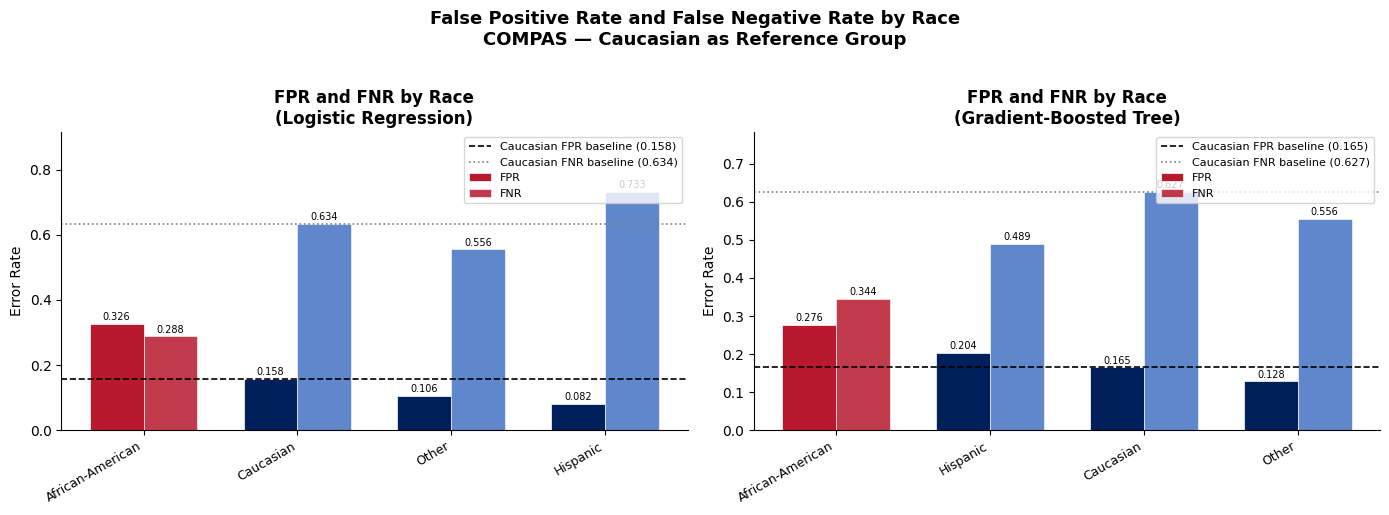

Figure saved → error_rate_disparity.png


In [56]:
# -------------------------------------------------------------------
# Visualize FPR and FNR by race (Caucasian as reference group)
# Publication-quality grouped bar chart — mirrors lecture style
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

navy, red = "#00205B", "#B8192C"

for ax, error_df, model_label in [
    (axes[0], lr_error_rates,  "Logistic Regression"),
    (axes[1], gbt_error_rates, "Gradient-Boosted Tree"),
]:
    er_plot = (
        error_df[error_df["n"] >= 50]
        .sort_values("FPR", ascending=False)
        .reset_index(drop=True)
    )

    x     = np.arange(len(er_plot))
    width = 0.35

    colors_fpr = [red if r == "African-American" else navy
                  for r in er_plot["race_factor"]]
    colors_fnr = [red if r == "African-American" else "#4472C4"
                  for r in er_plot["race_factor"]]

    bars1 = ax.bar(x - width / 2, er_plot["FPR"], width,
                   label="FPR", color=colors_fpr, edgecolor="white", linewidth=0.5)
    bars2 = ax.bar(x + width / 2, er_plot["FNR"], width,
                   label="FNR", color=colors_fnr, edgecolor="white", linewidth=0.5,
                   alpha=0.85)

    # Caucasian reference lines
    cau_fpr = er_plot.loc[er_plot["race_factor"] == "Caucasian", "FPR"].values
    cau_fnr = er_plot.loc[er_plot["race_factor"] == "Caucasian", "FNR"].values
    if len(cau_fpr):
        ax.axhline(cau_fpr[0], color="black", linestyle="--", linewidth=1.2,
                   label=f"Caucasian FPR baseline ({cau_fpr[0]:.3f})")
    if len(cau_fnr):
        ax.axhline(cau_fnr[0], color="grey",  linestyle=":",  linewidth=1.2,
                   label=f"Caucasian FNR baseline ({cau_fnr[0]:.3f})")

    ax.set_xticks(x)
    ax.set_xticklabels(er_plot["race_factor"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Error Rate")
    ax.set_title(f"FPR and FNR by Race\n({model_label})", fontweight="bold")
    ax.set_ylim(0, max(er_plot[["FPR","FNR"]].values.max() * 1.25, 0.5))
    ax.legend(fontsize=8, loc="upper right")
    ax.spines[["top","right"]].set_visible(False)

    # Value labels on bars
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle(
    "False Positive Rate and False Negative Rate by Race\n"
    "COMPAS — Caucasian as Reference Group",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("error_rate_disparity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → error_rate_disparity.png")